# Prerequistes

In [48]:
%pip install qiskit qiskit-aer pylatexenc


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


# Entanglement Swapping

1. Circuit Visualisation

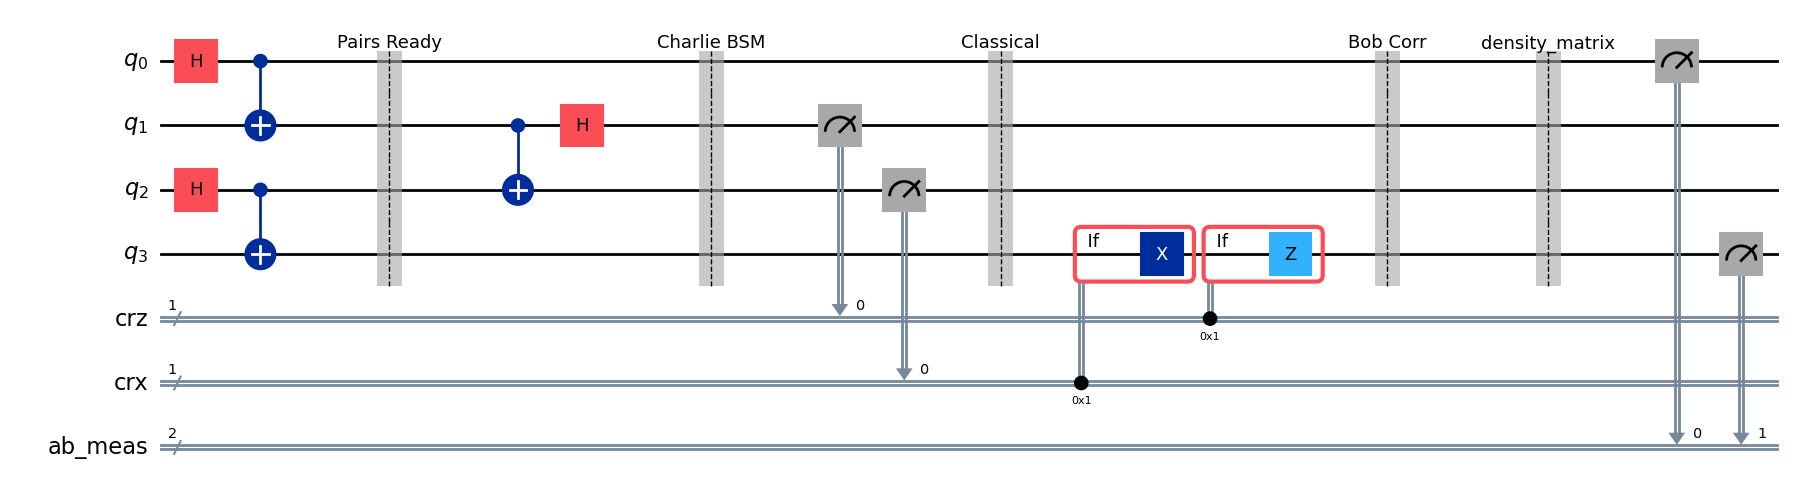

2. Quantum State Representation

Final DensityMatrix (Alice Q0 and Bob Q3 after swap):


<IPython.core.display.Latex object>

3. State Visualisation

Final State (Bloch Spheres for Q0 and Q3):


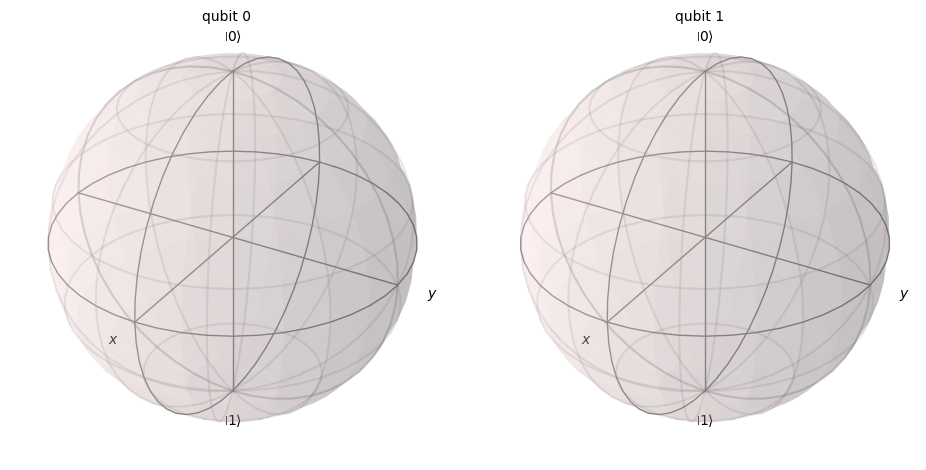


Final State (Q-Sphere for Q0 and Q3):


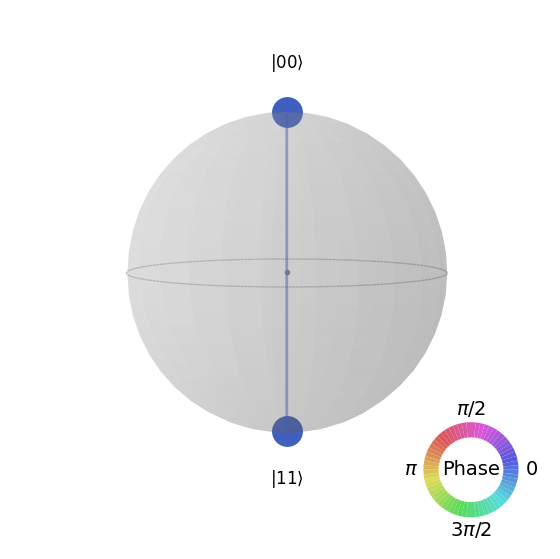

4. Measurement Analysis

Raw measurement counts: {'11 1 1': 137, '00 1 1': 132, '11 1 0': 134, '11 0 0': 122, '00 0 1': 131, '00 0 0': 114, '00 1 0': 135, '11 0 1': 119}


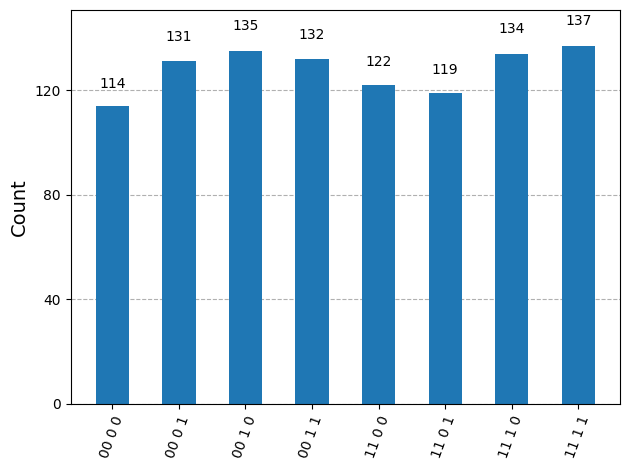

5. Verification

Entanglement Swapping Fidelity = 1.000000
Success: Q0 and Q3 are maximally entangled without ever interacting.


In [52]:
import numpy as np
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector, partial_trace, state_fidelity
from qiskit.visualization import plot_histogram, plot_bloch_multivector, plot_state_qsphere
from IPython.display import display, Markdown

# 1. Set up Registers & Circuit
qr = QuantumRegister(4, name="q")
crz = ClassicalRegister(1, name="crz")  # Charlie's Z measurement
crx = ClassicalRegister(1, name="crx")  # Charlie's X measurement
cr_ab = ClassicalRegister(2, name="ab_meas") # Final measurement for Alice and Bob
qc = QuantumCircuit(qr, crz, crx, cr_ab)

# 2. Prepare Pair 1 (Alice q0, Charlie q1)
qc.h(0)
qc.cx(0, 1)

# 3. Prepare Pair 2 (Charlie q2, Bob q3)
qc.h(2)
qc.cx(2, 3)
qc.barrier(label="Pairs Ready")

# 4. Charlie performs Bell State Measurement on q1 and q2
qc.cx(1, 2)
qc.h(1)
qc.barrier(label="Charlie BSM")

# 5. Charlie measures and sends classical bits
qc.measure(1, crz)
qc.measure(2, crx)
qc.barrier(label="Classical")

# 6. Bob applies dynamic corrections to q3 based on Charlie's bits
with qc.if_test((crx, 1)):
    qc.x(3)
with qc.if_test((crz, 1)):
    qc.z(3)
qc.barrier(label="Bob Corr")

# Save the full density matrix before final measurement collapses the state
qc.save_density_matrix()

# 7. Alice and Bob measure their qubits to prove correlation
qc.measure(0, cr_ab[0])
qc.measure(3, cr_ab[1])

# 8. Execute on AerSimulator
simulator = AerSimulator()
tqc = transpile(qc, simulator)
job = simulator.run(tqc, shots=1024)
result = job.result()

# ==========================================
# REQUIRED COURSEWORK OUTPUTS
# ==========================================

display(Markdown("1. Circuit Visualisation"))
display(qc.draw('mpl'))

display(Markdown("2. Quantum State Representation"))
# Extract the joint state of Alice (q0) and Bob (q3) by tracing out Charlie (q1, q2)
rho_full = result.data()['density_matrix']
rho_ab = partial_trace(rho_full, [1, 2])

print("Final DensityMatrix (Alice Q0 and Bob Q3 after swap):")
display(rho_ab.draw('latex'))

display(Markdown("3. State Visualisation"))
print("Final State (Bloch Spheres for Q0 and Q3):")
# Note: Bloch vectors will be length 0 (points at origin) because the individual 
# qubits in a Bell state are completely mixed when viewed locally.
display(plot_bloch_multivector(rho_ab))

print("\nFinal State (Q-Sphere for Q0 and Q3):")
display(plot_state_qsphere(rho_ab))

display(Markdown("4. Measurement Analysis"))
counts = result.get_counts()
print(f"Raw measurement counts: {counts}")
display(plot_histogram(counts))

display(Markdown("5. Verification"))
# The ideal target state is a perfect Bell state between Q0 and Q3
reference_circuit = QuantumCircuit(2)
reference_circuit.h(0)
reference_circuit.cx(0, 1)
ideal_state = Statevector(reference_circuit)

fidelity = state_fidelity(ideal_state, rho_ab)
print(f"Entanglement Swapping Fidelity = {fidelity:.6f}")
if np.isclose(fidelity, 1.0):
    print("Success: Q0 and Q3 are maximally entangled without ever interacting.")
else:
    print("Warning: Fidelity is less than 1.")